In [1]:
import h5py
# import jax
# jax.config.update("jax_enable_x64", True)
# from jax import numpy as jnp
# from jax import jit ,vmap
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
# from scipy.signal import convolve2d, fftconvolve # check jax
# from jax.scipy.signal import fftconvolve
# from jax.scipy.interpolate import RegularGridInterpolator
# from jax.scipy.ndimage import map_coordinates
import time

import os
import numpy
import numpy as np

from numpy.random import randint
import sklearn as sk
from sklearn.mixture import GaussianMixture # jaxxx??? # Hyakkk
from sklearn.decomposition import SparsePCA
from scipy.io import loadmat
import matplotlib as mpl
from matplotlib.colors import ListedColormap
# Seaborn colormap
import seaborn as sns
import colorcet as cc
sns_list = sns.color_palette(cc.glasbey,n_colors=20).as_hex()
sns_list.pop(4)

# sns_list.insert(0, '#ffffff')  # Insert white at zero position
sns_cmap = ListedColormap(sns_list)
cm = sns_cmap

sns_list_balance_models = sns_list.copy()

sns_list_balance_models.insert(0, '#ffffff')  # Insert white at zero position
sns_list_balance_models.pop(1)
sns_cmap_balance_models = ListedColormap(sns_list_balance_models)

cm_balance_models = sns_cmap_balance_models
mpl_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
            '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
            '#bcbd22', '#17becf']


In [2]:
labels = [r'$\bar{u} \bar{u}_x$', r'$\bar{v}\bar{u}_y$',
        r'$\nu \nabla \bar{\bf{u}}$', r'$\rho^{-1} \bar{p}_x$', 
        r'$\overline{({u^\prime} ^2)}_x$', r'$\overline{(u^\prime v^\prime)}_y$']

In [3]:
# load wavy wall data generated on the instutute lambda
# nc 12 trial 2
load_dir = '../results/'

nc = 12
trial = 0

cluster_idx = np.load(load_dir + f'nc{nc}/trial_{trial}/cluster_idx.npy')
masked_x_coords_DNS_grid = np.load(load_dir + f'nc{nc}/trial_{trial}/masked_x_coords_DNS_grid.npy')
masked_y_coords_DNS_grid = np.load(load_dir + f'nc{nc}/trial_{trial}/masked_y_coords_DNS_grid.npy')

nfeatures=6

# also load features
features = np.load(load_dir + 'terms/features.npy')

In [4]:
UU_x = features[:,0]
VU_y = features[:,1]
nu_Lap = features[:,2]
p_x = features[:,3]
Ruu_x = features[:,4]
Ruv_y = features[:,5]

In [5]:
# for i in range(1,nc+1):
#     print(i)
#     print(np.sum(cluster_idx == i))

In [6]:
# cluster_idx_ls = []
# for i in range(1,nc+1):
#     if np.sum(cluster_idx == i) == 0:
#         cluster_idx_ls.append(i-1)

In [7]:
clim = 1e-3

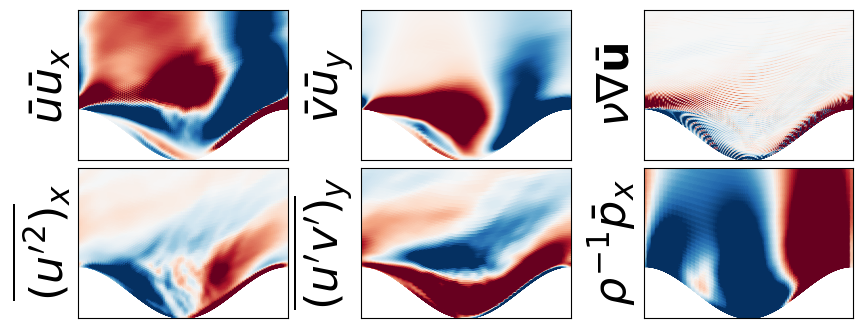

<Figure size 640x480 with 0 Axes>

In [8]:
# Plot all six terms in the RANS equation
fig = plt.figure(figsize=(10, 4))
# labels = [r'$\bar{u} \bar{u}_x$', r'$\bar{v}\bar{u}_y$', r'$\rho^{-1} \bar{p}_x$',
#           r'$\nu \nabla^2 \bar{u}$', r'$\overline{(u^\prime v^\prime)}_y$', r'$\overline{({u^\prime} ^2)}_x$']
# clim = 2e-1
fontsize=32

cmap = plt.colormaps['RdBu'].copy()
cmap.set_bad('white')


plt.subplot(231)
field = features[:,0]
plt.scatter(masked_x_coords_DNS_grid, masked_y_coords_DNS_grid, 2, field, vmin=-clim, vmax=clim, cmap=cmap)
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.xlim(1.0,3.0)
plt.ylim(0.0,0.58)
plt.ylabel(labels[0], fontsize=fontsize)

plt.subplot(232)
field = features[:,1]
plt.scatter(masked_x_coords_DNS_grid, masked_y_coords_DNS_grid, 2, field, vmin=-clim, vmax=clim, cmap=cmap)
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.xlim(1.0,3.0)
plt.ylim(0.0,0.58)
plt.ylabel(labels[1], fontsize=fontsize)

plt.subplot(233)
field = features[:,2]
plt.scatter(masked_x_coords_DNS_grid, masked_y_coords_DNS_grid, 2, field, vmin=-clim, vmax=clim, cmap=cmap)
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.xlim(1.0,3.0)
plt.ylim(0.0,0.58)
plt.ylabel(labels[2], fontsize=fontsize)

plt.subplot(236)
field = features[:,3]
plt.scatter(masked_x_coords_DNS_grid, masked_y_coords_DNS_grid, 2, field, vmin=-clim, vmax=clim, cmap=cmap)
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.xlim(1.0,3.0)
plt.ylim(0.0,0.58)
plt.ylabel(labels[3], fontsize=fontsize)

plt.subplot(234)
field = features[:,4]
plt.scatter(masked_x_coords_DNS_grid, masked_y_coords_DNS_grid, 2, field, vmin=-clim, vmax=clim, cmap=cmap)
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.xlim(1.0,3.0)
plt.ylim(0.0,0.58)
plt.ylabel(labels[4], fontsize=fontsize)

plt.subplot(235)
field = features[:,5]
plt.scatter(masked_x_coords_DNS_grid, masked_y_coords_DNS_grid, 2, field, vmin=-clim, vmax=clim, cmap=cmap)
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.xlim(1.0,3.0)
plt.ylim(0.0,0.58)
plt.ylabel(labels[5], fontsize=fontsize)

fig.patch.set_alpha(0)

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.35, hspace=0.05)

plt.savefig('DNSWavyWall_VanillaTerms_PressLast.png',dpi=480)#,bbox_inches='tight'

plt.show()
plt.clf()

# Do sPCA Process

In [9]:

def test_alpha_sPCA_GMM_model(alphas, features,cluster_idx,cluster_idx_to_test,nfeatures=6):
    err = np.zeros([len(alphas)])  # Error defined as norm of inactive terms
    sparsity = np.zeros([len(alphas)])
    for k in range(len(alphas)):
        i = cluster_idx_to_test
        # Identify points in the field corresponding to each cluster
        feature_idx = np.nonzero(cluster_idx==i)[0]
        cluster_features = features[feature_idx, :]
        spca = SparsePCA(n_components=1, alpha=alphas[k])
        spca.fit(cluster_features)
        active_terms = np.nonzero(spca.components_[0])[0]
        inactive_terms = [feat for feat in range(nfeatures) if feat not in active_terms ]

        err[k] += np.linalg.norm(cluster_features[:, inactive_terms])

    return err

In [10]:
cluster_err = []
alphas = 0.001*np.array([0.0000001,0.001,0.05,0.0625,0.075,0.0875,0.1,0.175,0.25,0.375,0.5,0.625,0.75,0.875,1,5,6,7,10,11,12,14,15,16,18,20,25,27.5,30,40,50,60,70,80,90,100,150,200,250,300,350,400,500,10000,100000])

for i in range(nc):
    if np.sum(cluster_idx-1 == i) == 0:
        cluster_err.append(np.zeros_like(alphas))
    else:
        cluster_err.append(test_alpha_sPCA_GMM_model(alphas, features, cluster_idx-1, i, nfeatures=6))

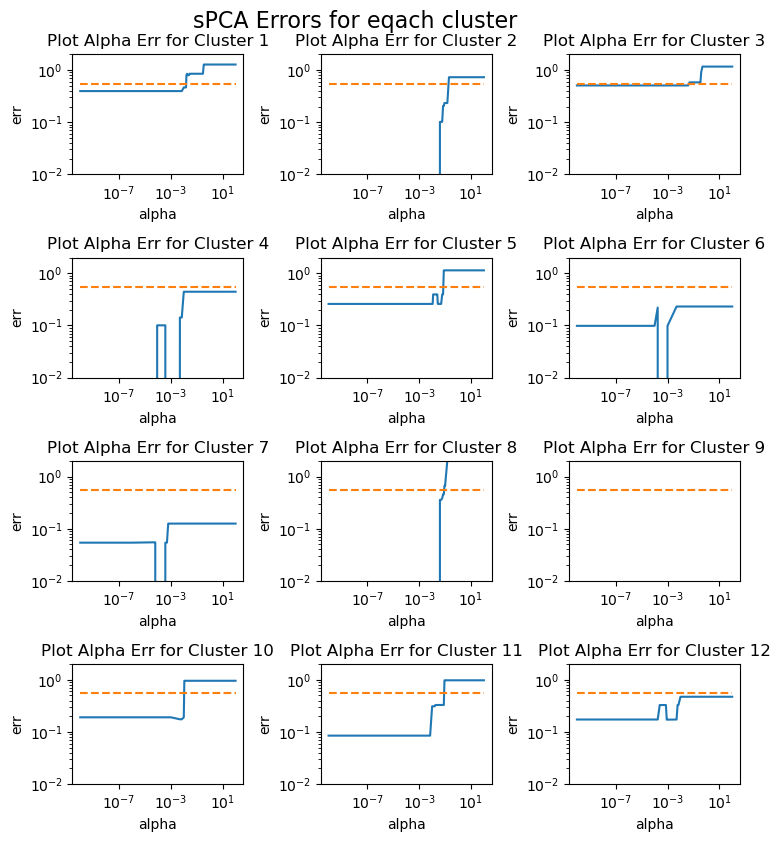

In [11]:
# Create figure and axes with 3x3 subplots, sharing the x-axis
fig, axes = plt.subplots(4, 3, figsize=(8, 9))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plotting
for i in range(nc):
    axes[i].loglog(alphas, cluster_err[i])
    axes[i].loglog(alphas, 0.55 * np.ones_like(np.array(alphas)), linestyle='--')
    axes[i].set_title(f'Plot Alpha Err for Cluster {i + 1}')
    # if i == 2:
    axes[i].set_ylim(0.01,2)
    axes[i].set_xlabel('alpha')
    axes[i].set_ylabel('err')

# # Add shared x-label and y-label
# fig.text(0.5, 0.04, 'X Axis', ha='center')
# fig.text(0.04, 0.5, 'Y Axis', va='center', rotation='vertical')

# Adjust layout
plt.tight_layout(rect=[0.05, 0.05, 1, 0.97])
plt.suptitle("sPCA Errors for eqach cluster", fontsize=16)
plt.show()

In [12]:
def train_sPCA_model_multi_alpha(opt_alpha_list, features, nfeatures, nc, cluster_idx):
    spca_model = np.zeros([nc, nfeatures])
    for i in range(nc):
        if np.sum(cluster_idx == i) == 0:
            print('found')
            continue
        else:
            print('next')
            alpha_opt = opt_alpha_list[i]
            feature_idx = np.nonzero(cluster_idx==i)[0]
            cluster_features = features[feature_idx, :]
            spca = SparsePCA(n_components=1, alpha=alpha_opt)
            spca.fit(cluster_features)
            # print('GMM Cluster {0}:'.format(i))
            active_terms = np.nonzero(spca.components_[0])[0]
            if len(active_terms)>0:
                # print([labels[k] for k in active_terms])
                spca_model[i, active_terms] = 1  # Set to 1 for active terms in model
            else: print('None')

    return spca_model

In [13]:
err_threshold = 0.55

alpha_opt = []
for i in range(nc):
    for j,err in enumerate(cluster_err[i]):
        if err > err_threshold:
            alpha_opt.append(alphas[j-1]) # append the last alpha value that was not above the error threshold
            break
        elif j == cluster_err[i].size - 1:
            alpha_opt.append(alphas[j-1]) # append the last alpha value if there are no alphas that surpass the error level
        else:
            continue

print(alpha_opt)

[0.015, 0.15, 0.04, 10.0, 0.07, 10.0, 10.0, 0.08, 10.0, 0.01, 0.08, 10.0]


In [14]:
optimal_alphas = alpha_opt
spca_model = train_sPCA_model_multi_alpha(optimal_alphas, features, nfeatures, nc, cluster_idx.flatten()-1)

next
next
next
next
None
next
next
None
next
None
next
found
next
next
next
None


In [15]:
balance_models, model_index = np.unique(spca_model, axis=0, return_inverse=True)

# print(balance_models)
nmodels = balance_models.shape[0]

balance_idx = np.array([model_index[i] for i in cluster_idx.flatten() - 1])

In [16]:
#  and masked_x_coords_DNS_grid<1.1 and masked_x_coords_DNS_grid>2.9
mask = np.where(masked_y_coords_DNS_grid<0.6) # cutoff the y axis to match the PIV domain... might be cutting off too much...

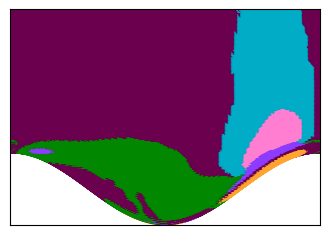

<Figure size 640x480 with 0 Axes>

In [18]:
# Save balance_model and balance maps & plot them too
fig = plt.figure(figsize = (4,2.8))
cmap_white= cm.copy()
cmap_white.set_bad('white')
plt.scatter(masked_x_coords_DNS_grid[mask],masked_y_coords_DNS_grid[mask], 2, balance_idx[mask]+1, cmap = cmap_white, vmin=-0.5, vmax=cm.N-0.5)

plt.gca().set_facecolor('white')
plt.gca().patch.set_alpha(1.0)
plt.xticks([])
plt.yticks([])
plt.xlim(np.min(masked_x_coords_DNS_grid[mask]),np.max(masked_x_coords_DNS_grid[mask]))
plt.ylim(0,np.max(masked_y_coords_DNS_grid[mask]))
fig.patch.set_alpha(0)
fig.patch.set_facecolor('none')

plt.savefig(f'sPCA_ClusterDomain_WW_DNS_pointwise.png',dpi=480,bbox_inches='tight')
plt.show()
plt.clf()

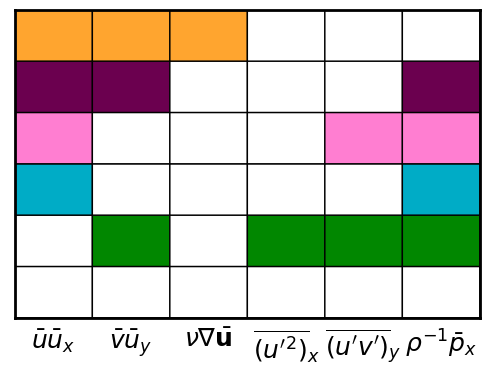

<Figure size 640x480 with 0 Axes>

In [19]:
# Plot a grid with active terms in each cluster
gridmap = balance_models.copy()
gridmask = gridmap==0
gridmap = (gridmap.T*np.arange(nmodels)).T+1  # Scale map so that active terms can be color-coded
gridmap[gridmask] = 0

grid_labels_pressure = [r'$\bar{u} \bar{u}_x$', r'$\bar{v}\bar{u}_y$',
                    r'$\nu \nabla \bar{\bf{u}}$', 
                    r'$\overline{({u^\prime} ^2)}_x$', r'$\overline{(u^\prime v^\prime)}_y$', r'$\rho^{-1} \bar{p}_x$']

gridmap_pressure = np.vstack([gridmap.T,gridmap[:,3]]).T[:,[0,1,2,4,5,6]]

plt.figure(figsize=(6, 4))
plt.pcolor(gridmap_pressure, vmin=-0.5, vmax=cm.N-0.5, cmap=cm_balance_models, edgecolors='k', linewidth=1)
plt.gca().set_xticks(np.arange(0.5, gridmap_pressure.shape[1]+0.5))
plt.gca().set_xticklabels(grid_labels_pressure, fontsize=18)
plt.gca().set_yticklabels([])

for axis in ['top','bottom','left','right']:
    plt.gca().spines[axis].set_linewidth(2)

plt.gca().tick_params(axis='both', width=0)

plt.savefig(f'sPCA_Matrix_Model_WW_DNS_Vanilla.png',bbox_inches='tight',transparent=True)
# plt.savefig(save_dir + f'trial{i}/sPCA_Matrix_Model')
plt.show()
plt.clf()

# save cluster_idx np array and spca_model np
# np.save(save_dir + f'trial{i}/spca_model.npy', balance_models)
# np.save(save_dir + f'trial{i}/cluster_idx.npy', balancemap)

In [ ]:
# np.save('../post_sPCA_arrays/cluster_idx_to_fill_DNS.npy',balance_idx)

# Explanation

While the finite difference for the DNS appears to have constructed an equation space that has less sporadic noise than the PIV on an equivalent grid, there are still significant artifacts from lossy upsampling, caused by numerical differentiation, that prevent successful clustering and identification of dynamics. These are visible as corrupted manifolds in equation space. This is not a problem for the weak for which takes in local information from beyond simply it's immediate neighbors, leading to better reconstruction of terms due to the inherent advantage of integration when handling noisy or artifacted data. Perhaps additional smoothing of the resulting equation space from finite difference could acheive decent results, but it removes the mathematical foundation of weak solutions generating fields that are actual solutions to the governing equation, not smoothed approximations to make them look like valid solutions.